## 08 — Upload ONNX Models to Supabase Storage

Uploads the three `.onnx` files to the `models` bucket in Supabase Storage.  
The bucket is created as **public** so the frontend can fetch models directly via URL.  

**Prerequisites:** run notebooks 04–07 first.  
**Required env var:** `SUPABASE_SERVICE_ROLE_KEY` (Settings → API → service_role key)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('dark_background')
ACCENT  = '#3b82f6'
SUCCESS = '#22c55e'
MODELS_DIR = Path('..') / 'models'
BUCKET = 'models'
ONNX_FILES = [
    'wait_time_model.onnx',
    'outcome_model.onnx',
    'satisfaction_model.onnx',
]

print('Libraries loaded')

Libraries loaded


### 1. Configure Credentials

Set your Supabase URL and service role key.  
Get the service role key from: **Supabase dashboard → Project Settings → API → service_role**

In [ ]:
SUPABASE_URL = os.environ.get('SUPABASE_URL', os.environ.get('NEXT_PUBLIC_SUPABASE_URL', ''))
SERVICE_ROLE_KEY = os.environ.get('SUPABASE_SERVICE_ROLE_KEY', '')

if not SUPABASE_URL:
    raise EnvironmentError('Set SUPABASE_URL env var')
if not SERVICE_ROLE_KEY:
    raise EnvironmentError(
        'Set SUPABASE_SERVICE_ROLE_KEY env var before running this notebook.\n'
        'Find it at: Supabase dashboard → Project Settings → API → service_role.\n'
        'In PowerShell: $env:SUPABASE_SERVICE_ROLE_KEY = "your-key-here"'
    )

HEADERS = {
    'apikey': SERVICE_ROLE_KEY,
    'Authorization': f'Bearer {SERVICE_ROLE_KEY}',
}
print(f'Supabase URL : {SUPABASE_URL}')
print(f'Key preview  : {SERVICE_ROLE_KEY[:12]}...')

### 2. Check ONNX Files Exist

In [3]:
all_present = True
for fname in ONNX_FILES:
    p = MODELS_DIR / fname
    size_kb = p.stat().st_size / 1024 if p.exists() else 0
    status = f'{size_kb:.1f} KB' if p.exists() else 'MISSING — run 07_export_onnx first'
    print(f'{fname:<32}  {status}')
    if not p.exists():
        all_present = False

print(f'\nAll files present: {all_present}')

wait_time_model.onnx              188.5 KB
outcome_model.onnx                670.8 KB
satisfaction_model.onnx           189.8 KB

All files present: True


### 3. Create Storage Bucket

In [4]:
r = requests.get(f'{SUPABASE_URL}/storage/v1/bucket/{BUCKET}', headers=HEADERS)
if r.status_code == 200:
    print(f"Bucket '{BUCKET}' already exists")
else:
    payload = {'id': BUCKET, 'name': BUCKET, 'public': True}
    r = requests.post(f'{SUPABASE_URL}/storage/v1/bucket', json=payload, headers=HEADERS)
    if r.status_code in (200, 201):
        print(f"Bucket '{BUCKET}' created (public=True)")
    else:
        raise RuntimeError(f'Failed to create bucket: {r.status_code} {r.text}')

Bucket 'models' created (public=True)


### 4. Upload ONNX Models

In [5]:
upload_headers = {
    **HEADERS,
    'Content-Type': 'application/octet-stream',
    'x-upsert': 'true',
}

results = []
for fname in ONNX_FILES:
    path = MODELS_DIR / fname
    with open(path, 'rb') as f:
        data = f.read()

    url = f'{SUPABASE_URL}/storage/v1/object/{BUCKET}/{fname}'
    r = requests.post(url, headers=upload_headers, data=data)

    size_kb = len(data) / 1024
    if r.status_code in (200, 201):
        public_url = f'{SUPABASE_URL}/storage/v1/object/public/{BUCKET}/{fname}'
        print(f'OK    {fname:<32}  {size_kb:.1f} KB')
        results.append({'file': fname, 'size_kb': round(size_kb, 1),
                         'status': 'uploaded', 'url': public_url})
    else:
        print(f'FAIL  {fname}  {r.status_code}: {r.text}')
        results.append({'file': fname, 'size_kb': round(size_kb, 1),
                         'status': 'failed', 'url': ''})

print(f'\nUploaded {sum(r["status"]=="uploaded" for r in results)}/{len(results)} models')

OK    wait_time_model.onnx              188.5 KB
OK    outcome_model.onnx                670.8 KB
OK    satisfaction_model.onnx           189.8 KB

Uploaded 3/3 models


### 5. Verify — Download and Run Inference

In [6]:
import numpy as np
import onnxruntime as rt
import tempfile

test_rec = results[0]  # wait_time_model.onnx
if test_rec['status'] != 'uploaded':
    print('Skipping verification — upload failed')
else:
    print(f'Downloading {test_rec["file"]} from Supabase...')
    r = requests.get(test_rec['url'])
    print(f'Status: {r.status_code}  Size: {len(r.content)/1024:.1f} KB')

    with tempfile.NamedTemporaryFile(suffix='.onnx', delete=False) as tmp:
        tmp.write(r.content)
        tmp_path = tmp.name

    sess = rt.InferenceSession(tmp_path, providers=['CPUExecutionProvider'])
    dummy = np.random.rand(3, 16).astype(np.float32)
    iname = sess.get_inputs()[0].name
    preds = sess.run(None, {iname: dummy})[0]
    print(f'Inference OK — output shape: {preds.shape}  sample: {preds.flatten()[:3].round(2)}')
    os.unlink(tmp_path)

Status: 200  Size: 188.5 KB
Inference OK — output shape: (3, 1)  sample: [198.57 198.57 198.57]


### 6. Public URLs Summary


ONNX Model Public URLs:
wait_time_model.onnx              188.5 KB
  URL: https://xcthkhpvdfvhiedzeuji.supabase.co/storage/v1/object/public/models/wait_time_model.onnx
outcome_model.onnx                670.8 KB
  URL: https://xcthkhpvdfvhiedzeuji.supabase.co/storage/v1/object/public/models/outcome_model.onnx
satisfaction_model.onnx           189.8 KB
  URL: https://xcthkhpvdfvhiedzeuji.supabase.co/storage/v1/object/public/models/satisfaction_model.onnx



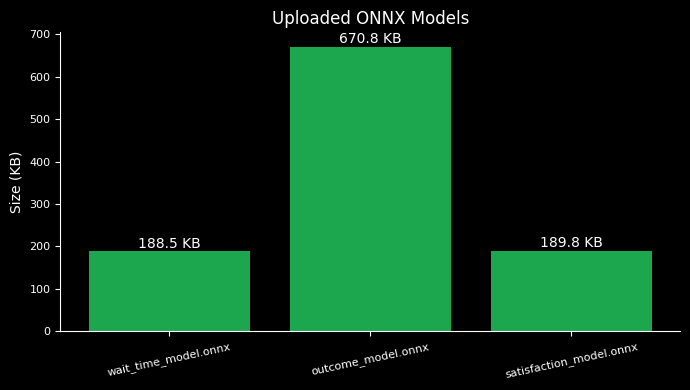

Models available at Supabase Storage — ready for frontend fetch.


In [7]:
df = pd.DataFrame(results)
print('\nONNX Model Public URLs:')
print('=' * 80)
for _, row in df.iterrows():
    print(f"{row['file']:<32}  {row['size_kb']} KB")
    if row['url']:
        print(f"  URL: {row['url']}")
print()

fig, ax = plt.subplots(figsize=(7, 4))
colors = [SUCCESS if s == 'uploaded' else '#ef4444' for s in df['status']]
bars = ax.bar(df['file'], df['size_kb'], color=colors, alpha=0.85)
for bar, val in zip(bars, df['size_kb']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val} KB', ha='center', va='bottom', color='white', fontsize=10)
ax.set_ylabel('Size (KB)', color='white')
ax.set_title('Uploaded ONNX Models', color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=8)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

print('Models available at Supabase Storage — ready for frontend fetch.')